# Purpose:
- Calculating adjusted variance explained for those with low # of frames of support (e.g., omissions)
- Other functions to calculate derived values from GLM fit
- Ultimately these will be added to glm_analysis_tools.py

# Issues
- NaNs from partial model
    - It was due to having nan values in X and W (these need to be filtered)
- Too low from full model
    - It was because weights in X and W are not ordered the same (use xarray @ directly, instead of calling values)

# Conclusion
- use coding score calculation from the session model 
- Less noisier.
- Need to think about this more later, but for now...

# Conclusion
- Assume they are correct.
    - Correlations are not great, but this can be an inherent problem with coding score calculation.
        - Asked questions to Marina and Iryna.
    - Proceed with this while
        - Curation response stats (https://codeocean.allenneuraldynamics.org/capsule/6152025/tree)
        - Checking with Marina and Iryna if there's any other way of validation.
- Follow up from 250127_calculate_and_save_coding_score.ipynb

In [1]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



In [55]:
def generate_adjusted_variance_explained(glm_results, run_params, X_trim, response_trim_filtered):
    adj_var_explained_test_cv = xr.full_like(glm_results['var_explained_test_cv'],
                                         fill_value=np.nan).drop_sel(model=['Full', 'intercept'])
    adj_var_explained_test_cv_full_mask = xr.full_like(glm_results['var_explained_test_cv'],
                                                        fill_value=np.nan).drop_sel(model=['Full', 'intercept'])

    all_weights = glm_results['W_cv'].weights.values
    all_models = adj_var_explained_test_cv.model.values
    for model in all_models:
        run_param = run_params['dropouts'][model]
        if run_param['is_single']:
            kernels = run_param['kernels']
        else:
            kernels = run_param['dropped_kernels']
        # remove intercept from kernels for the mask
        kernels = np.setdiff1d(kernels, ['intercept'])
        
        mask_weights = [w for w in all_weights if np.any([mk in w for mk in kernels])]
        mask_trim = (X_trim.sel(weights=mask_weights)!=0).any(dim='weights')
        if mask_trim.sum() == X_trim.sizes['timestamps']:
            adj_var_explained_test_cv.loc[{'model': model}] = glm_results['var_explained_test_cv'].sel(model=model)
            adj_var_explained_test_cv_full_mask.loc[{'model': model}] = glm_results['var_explained_test_cv'].sel(model='Full')
        else:
            if run_param['is_single']:
                run_weights = ['intercept_0', *mask_weights]
            else:
                run_weights = np.setdiff1d(all_weights, mask_weights)
            for cv_ind in range(glm_results['fit_params']['cv_fold']): # TODO: this loop can be removed?
                train_frames, test_frames, nested_fold_inds= \
                    gft.get_train_test_inds(cv_ind, glm_results['fit_params'],
                                        glm_results['stratified_frames'],
                                        glm_results['cv_inds_stratified'])

                X_test_cv = X_trim[test_frames, :]
                y_test_cv = response_trim_filtered[test_frames, :]
                mask_cv = (X_test_cv.sel(weights=mask_weights)!=0).any(dim='weights')
                W_cv = glm_results['W_cv'].sel(test_fold_ind=cv_ind, model=model)
                
                W_cv_model = W_cv.sel(weights=run_weights)
                X_test_cv_model = X_test_cv.sel(weights=run_weights)
                assert np.isnan(W_cv_model).any() == False
                
                adj_var_explained_test_cv.loc[{'model': model, 'test_fold_ind': cv_ind}] = \
                    gft.compute_adjusted_variance_explained(y_test_cv, W_cv_model, X_test_cv_model, mask_cv)
                
                W_cv_full = glm_results['W_cv'].sel(test_fold_ind=cv_ind, model='Full')
            
                adj_var_explained_test_cv_full_mask.loc[{'model': model, 'test_fold_ind': cv_ind}] = \
                    gft.compute_adjusted_variance_explained(y_test_cv, W_cv_full, X_test_cv, mask_cv)
    return adj_var_explained_test_cv, adj_var_explained_test_cv_full_mask

In [3]:
data_type = 'events'
dm_version = 1
load_path = Path('/root/capsule/scratch/Thyme')
save_dir = load_path

data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                    ('dlc-eye' not in d.split('/')[-1]) and
                    ('multiplane-ophys' in d.split('/')[-1]) and 
                    ('stimuli' not in d.split('/')[-1]) and
                    ('stim-response' not in d.split('/')[-1]) and
                    ('ROICat' not in d.split('/')[-1])])
session_names = [d.split('/')[-1] for d in raw_paths]
session_names

['multiplane-ophys_736963_2024-07-24_08-49-57',
 'multiplane-ophys_736963_2024-07-26_09-37-45',
 'multiplane-ophys_736963_2024-07-29_09-00-58',
 'multiplane-ophys_736963_2024-07-30_09-11-03',
 'multiplane-ophys_736963_2024-08-01_08-59-00',
 'multiplane-ophys_736963_2024-08-05_09-19-25',
 'multiplane-ophys_736963_2024-08-06_08-52-03',
 'multiplane-ophys_736963_2024-08-07_09-11-10',
 'multiplane-ophys_736963_2024-08-09_08-58-36',
 'multiplane-ophys_736963_2024-08-12_09-17-19',
 'multiplane-ophys_736963_2024-08-13_08-57-29']

In [4]:
suffix = '_00'
session_name = session_names[5]
glm_fn = load_path / f'glm_results_v{dm_version:02}_{session_name}_{data_type}{suffix}.npy'
glm_results = np.load(glm_fn, allow_pickle=True).item()

X, response, response_info, run_params, unstd_features, use_indices = \
    gft.load_data(session_name, data_type, dm_version, load_path=load_path)

# trim X and response based on the shift
X_trim = X[use_indices, :]
response_trim = response[use_indices, :]
response_trim_filtered = gft.filter_response_matrix(response_trim)

In [ ]:
adj_ve_test_cv, adj_ve_test_cv_full_mask = \
    generate_adjusted_variance_explained(glm_results, run_params,
                                         X_trim, response_trim_filtered)

In [106]:
glm_results.keys()

dict_keys(['fit_params', 'use_indices', 'stratified_frames', 'cv_inds_stratified', 'lambdas_cv', 'W_cv', 'var_explained_train_cv', 'var_explained_test_cv', 'vr_test_train_ratio_cv', 'var_explained_mean_model'])

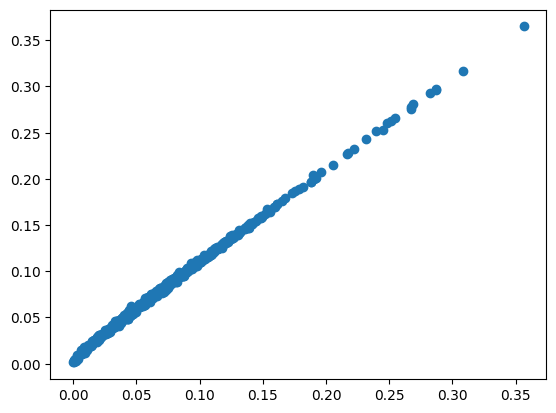

In [109]:
ve_from_mean_across_fold = glm_results['var_explained_test_cv'].mean(dim='test_fold_ind').sel(model='Full').values
ve_from_mean_model = glm_results['var_explained_mean_model'].sel(model='Full')
fig, ax = plt.subplots()
ax.scatter(ve_from_mean_across_fold, ve_from_mean_model)

Text(0, 0.5, 'Count')

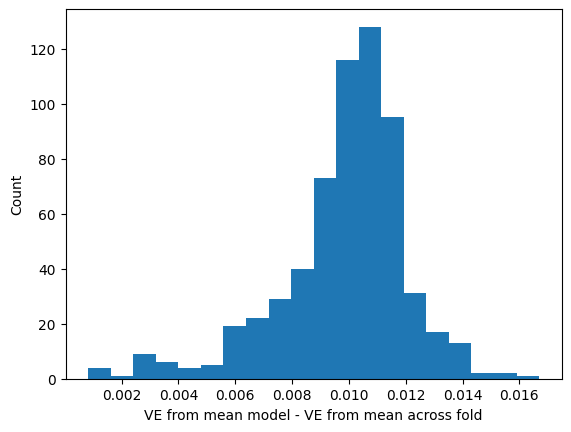

In [111]:
fig, ax = plt.subplots()
ax.hist(ve_from_mean_model - ve_from_mean_across_fold, bins=20);
ax.set_xlabel('VE from mean model - VE from mean across fold')
ax.set_ylabel('Count')


Text(0, 0.5, 'Cumulative fraction')

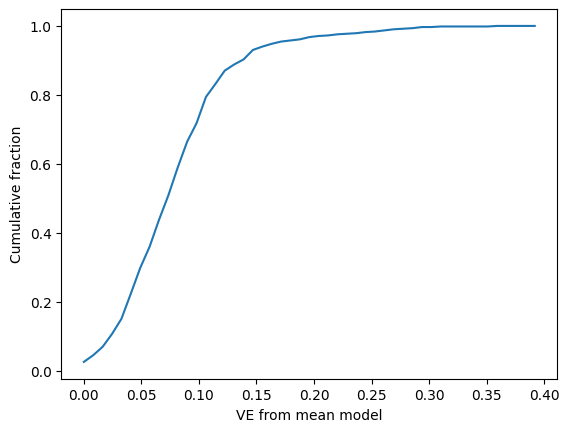

In [117]:
bins = np.linspace(0, 0.4, 50)
ve_from_mean_model_clipped = np.clip(ve_from_mean_model, a_min=0, a_max=None)
cumhist = np.cumsum(np.histogram(ve_from_mean_model, bins=bins)[0]) / len(ve_from_mean_model)

fig, ax = plt.subplots()
ax.plot(bins[:-1], cumhist)
ax.set_xlabel('VE from mean model')
ax.set_ylabel('Cumulative fraction')


In [7]:
# dev code for calculating coding score
# For now, just follow Alex's code 
# -(adj_ve_partial / adj_ve_full) for "single" models
# -(1 - (adj_ve_partial / adj_ve_full)) for the rest ("drop-out" models)
# Ignore 'Full' and 'intercept' models
adj_coding_score = xr.full_like(adj_ve_test_cv,
                                fill_value=np.nan)

models = adj_ve_test_cv.model.values
single_models = [m for m in models if run_params['dropouts'][m]['is_single']]
dropout_models = [m for m in models if not run_params['dropouts'][m]['is_single']]

adj_coding_score.loc[{'model': single_models}] = -adj_ve_test_cv.sel(model=single_models) / adj_ve_test_cv_full_mask.sel(model=single_models)
adj_coding_score.loc[{'model': dropout_models}] = -(1 - (adj_ve_test_cv.sel(model=dropout_models) / adj_ve_test_cv_full_mask.sel(model=dropout_models)))

In [54]:
# dev code to compute adjusted variance explained
# if mask is all true, then no need to compute adjusted variance explained
# just copy the value from the glm_results
# For those of _full_mask for coding score normalization (1- (adj_ve_partial / adj_ve_full)),
# Copy ve of Full model
# takes about 1 min

adj_var_explained_test_cv = xr.full_like(glm_results['var_explained_test_cv'],
                                         fill_value=np.nan).drop_sel(model=['Full', 'intercept'])
adj_var_explained_test_cv_full_mask = xr.full_like(glm_results['var_explained_test_cv'],
                                                    fill_value=np.nan).drop_sel(model=['Full', 'intercept'])

all_weights = glm_results['W_cv'].weights.values
all_models = adj_var_explained_test_cv.model.values
for model in all_models:
    
    run_param = run_params['dropouts'][model]
    if run_param['is_single']:
        kernels = run_param['kernels']
    else:
        kernels = run_param['dropped_kernels']
    # remove intercept from kernels for the mask
    kernels = np.setdiff1d(kernels, ['intercept'])
    
    mask_weights = [w for w in all_weights if np.any([mk in w for mk in kernels])]
    mask_trim = (X_trim.sel(weights=mask_weights)!=0).any(dim='weights')
    if mask_trim.sum() == X_trim.sizes['timestamps']:
        adj_var_explained_test_cv.loc[{'model': model}] = glm_results['var_explained_test_cv'].sel(model=model)
        adj_var_explained_test_cv_full_mask.loc[{'model': model}] = glm_results['var_explained_test_cv'].sel(model='Full')
    else:
        if run_param['is_single']:
            run_weights = ['intercept_0', *mask_weights]
        else:
            run_weights = np.setdiff1d(all_weights, mask_weights)
        for cv_ind in range(glm_results['fit_params']['cv_fold']):
            train_frames, test_frames, nested_fold_inds= \
                gft.get_train_test_inds(cv_ind, glm_results['fit_params'],
                                    glm_results['stratified_frames'],
                                    glm_results['cv_inds_stratified'])

            X_test_cv = X_trim[test_frames, :]
            y_test_cv = response_trim_filtered[test_frames, :]
            mask_cv = (X_test_cv.sel(weights=mask_weights)!=0).any(dim='weights')
            W_cv = glm_results['W_cv'].sel(test_fold_ind=cv_ind, model=model)
            
            W_cv_model = W_cv.sel(weights=run_weights)
            X_test_cv_model = X_test_cv.sel(weights=run_weights)
            assert np.isnan(W_cv_model).any() == False
            
            adj_var_explained_test_cv.loc[{'model': model, 'test_fold_ind': cv_ind}] = \
                gft.compute_adjusted_variance_explained(y_test_cv, W_cv_model, X_test_cv_model, mask_cv)
            
            W_cv_full = glm_results['W_cv'].sel(test_fold_ind=cv_ind, model='Full')
        
            adj_var_explained_test_cv_full_mask.loc[{'model': model, 'test_fold_ind': cv_ind}] = \
                gft.compute_adjusted_variance_explained(y_test_cv, W_cv_full, X_test_cv, mask_cv)
                
            
            

In [56]:
adj_var_explained_test_cv, adj_var_explained_test_cv_full_mask = \
    generate_adjusted_variance_explained(glm_results, run_params, X_trim, response_trim_filtered)

In [70]:
assert len(np.where(np.isinf(adj_var_explained_test_cv))[0])==0
assert len(np.where(np.isinf(adj_var_explained_test_cv_full_mask))[0])==0

assert len(np.where(np.isnan(adj_var_explained_test_cv))[0])==0
assert len(np.where(np.isnan(adj_var_explained_test_cv_full_mask))[0])==0

# Coding score
- (1) Take average of adjusted variance explained and calculat coding score afterwards
    - With or without filtering (0.005)
- (2) calculate coding score per cv and average them
    - With or without filtering (0.005)
- (3) Calculate adjusted variance explained from the whole session model (mean W) and then calculate coding score
### Compare with mean responses (images, changes, omissions)


In [147]:
models = adj_var_explained_test_cv.model.values

mean_adjVE_cv = adj_var_explained_test_cv.mean(dim='test_fold_ind')
mean_adjVE_cv_full_mask = adj_var_explained_test_cv_full_mask.mean(dim='test_fold_ind')
coding_score_from_mean = xr.full_like(mean_adjVE_cv, fill_value=np.nan)

single_models = [m for m in models if run_params['dropouts'][m]['is_single']]
dropout_models = [m for m in models if not run_params['dropouts'][m]['is_single']]

coding_score_from_mean.loc[{'model': single_models}] = -mean_adjVE_cv.sel(model=single_models) / mean_adjVE_cv_full_mask.sel(model=single_models)
coding_score_from_mean.loc[{'model': dropout_models}] = -(1 - (mean_adjVE_cv.sel(model=dropout_models) / mean_adjVE_cv_full_mask.sel(model=dropout_models)))

# filtering
coding_score_from_mean_filtered_before_clipping = coding_score_from_mean.copy()
threshold = 0.005

mean_adjVE_mask = mean_adjVE_cv < threshold
mean_adjVE_full_mask_mask = mean_adjVE_cv_full_mask < threshold
coding_score_from_mean_filtered_before_clipping = coding_score_from_mean_filtered_before_clipping.where(
    ~(mean_adjVE_mask + mean_adjVE_full_mask_mask), other=0)

# clipping
coding_score_from_mean_filtered = coding_score_from_mean_filtered_before_clipping.clip(min=-1, max=0)


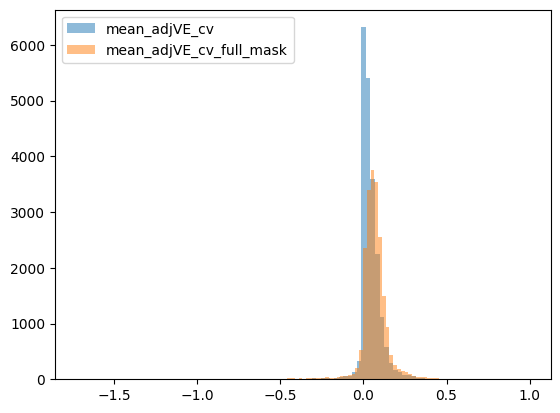

In [79]:
fig, ax = plt.subplots()
ax.hist(mean_adjVE_cv.values.flatten(), bins=100, alpha=0.5, label='mean_adjVE_cv');
ax.hist(mean_adjVE_cv_full_mask.values.flatten(), bins=100, alpha=0.5, label='mean_adjVE_cv_full_mask');
ax.legend()

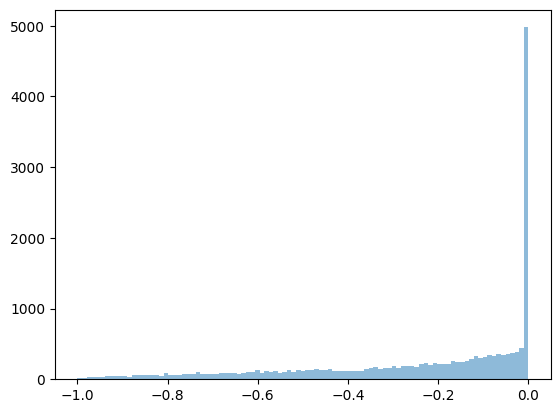

In [82]:
fig, ax = plt.subplots()
ax.hist(coding_score_from_mean_filtered.values.flatten(), bins=np.linspace(-1, 0, 100), alpha=0.5, label='coding_score_from_mean_filtered');

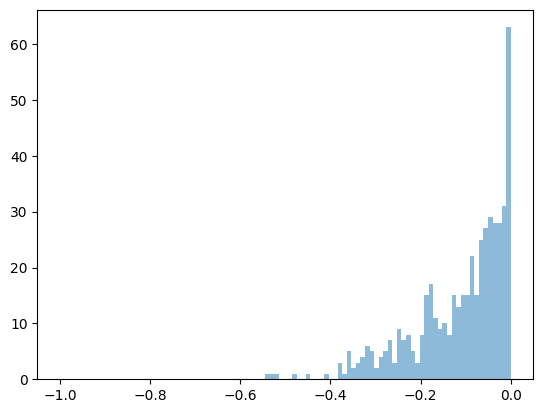

In [83]:
plt.hist(coding_score_from_mean_filtered.sel(model='omissions').values, bins=np.linspace(-1, 0, 100), alpha=0.5, label='omissions');

In [89]:
np.sort(coding_score_from_mean_filtered.cell_roi_id.values[coding_score_from_mean_filtered.sel(model='omissions')<-0.3])

array(['VISp_0_0002', 'VISp_0_0026', 'VISp_0_0035', 'VISp_0_0036',
       'VISp_0_0050', 'VISp_0_0051', 'VISp_0_0060', 'VISp_0_0062',
       'VISp_0_0064', 'VISp_1_0002', 'VISp_1_0020', 'VISp_1_0050',
       'VISp_2_0005', 'VISp_2_0037', 'VISp_2_0049', 'VISp_2_0060',
       'VISp_3_0038', 'VISp_3_0051', 'VISp_4_0005', 'VISp_4_0038',
       'VISp_4_0044', 'VISp_4_0045', 'VISp_4_0051', 'VISp_4_0059',
       'VISp_5_0010', 'VISp_5_0047', 'VISp_5_0073', 'VISp_5_0074',
       'VISp_5_0075', 'VISp_5_0082', 'VISp_5_0089', 'VISp_6_0024',
       'VISp_6_0050', 'VISp_7_0066', 'VISp_7_0080', 'VISp_7_0088'],
      dtype=object)

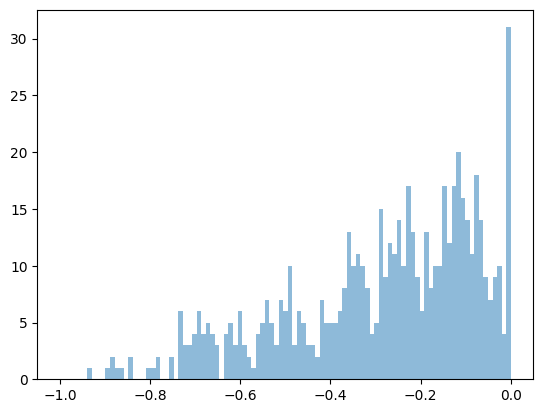

In [90]:
plt.hist(coding_score_from_mean_filtered.sel(model='all-images').values, bins=np.linspace(-1, 0, 100), alpha=0.5, label='all-images');

### Coding score from folds

In [151]:
models = adj_var_explained_test_cv.model.values

coding_score_from_cv = xr.full_like(adj_var_explained_test_cv, fill_value=np.nan)

single_models = [m for m in models if run_params['dropouts'][m]['is_single']]
dropout_models = [m for m in models if not run_params['dropouts'][m]['is_single']]

coding_score_from_cv.loc[{'model': single_models}] = -adj_var_explained_test_cv.sel(model=single_models) / adj_var_explained_test_cv_full_mask.sel(model=single_models)
coding_score_from_cv.loc[{'model': dropout_models}] = -(1 - (adj_var_explained_test_cv.sel(model=dropout_models) / adj_var_explained_test_cv_full_mask.sel(model=dropout_models)))

threshold = 0.005
adjVE_mask = adj_var_explained_test_cv < threshold
adjVE_full_mask_mask = adj_var_explained_test_cv_full_mask < threshold
coding_score_avg_from_cv_filtered_before_clipping = coding_score_from_cv.copy()
coding_score_avg_from_cv_filtered_before_clipping = coding_score_avg_from_cv_filtered_before_clipping.where(~(adjVE_mask + adjVE_full_mask_mask), other=0)

coding_score_avg_from_cv = coding_score_from_cv.mean(dim='test_fold_ind')
coding_score_avg_from_cv_filtered_before_clipping = coding_score_avg_from_cv_filtered_before_clipping.mean(dim='test_fold_ind')

# clipping
coding_score_avg_from_cv = coding_score_avg_from_cv.clip(min=-1, max=0)
coding_score_avg_from_cv_filtered = coding_score_avg_from_cv_filtered_before_clipping.clip(min=-1, max=0)


In [123]:
coding_score_avg_from_cv_filtered.min()

<xarray.DataArray ()> Size: 8B
array(-1.)

Text(0, 0.5, 'CS calculated from the avg of ve across folds')

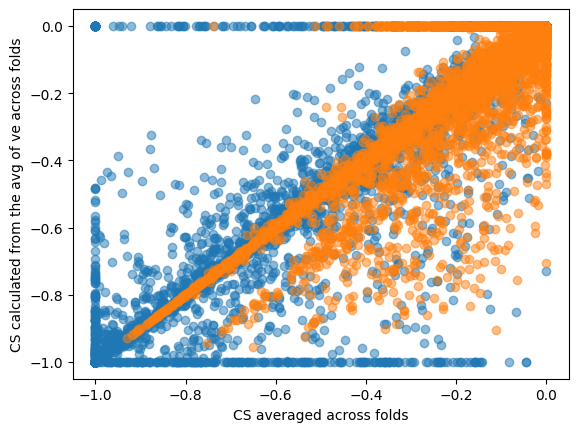

In [129]:
fig, ax = plt.subplots()
ax.scatter(coding_score_avg_from_cv_filtered.sel(model=single_models).values.flatten(),
           coding_score_from_mean_filtered.sel(model=single_models).values.flatten(),
           alpha=0.5)
ax.scatter(coding_score_avg_from_cv_filtered.sel(model=dropout_models).values.flatten(),
           coding_score_from_mean_filtered.sel(model=dropout_models).values.flatten(),
           alpha=0.5)
ax.set_xlabel('CS averaged across folds')
ax.set_ylabel('CS calculated from the avg of ve across folds')

## Too high coding score from dropouts
- Too low coding score from single
- Where are these from?
- Original calculation clipped them (Alex's GLM fit tools. )
    - Cleaning Steps, careful eye here! 
        - If the single-dropout explained more variance than the full_comparison, clip dropout to -1
        - If the single-dropout explained less than THRESHOLD variance, clip dropout to 0 
        - If the full_comparison model explained less than THRESHOLD variance, clip the dropout to 0.
        - If the dropout explained more variance than the full_comparison, clip the dropout to 0
        - If the full_comparison model explained less than THRESHOLD variance, clip the dropout to 0

## coding scores from session model
- averaged W

In [102]:
glm_results.keys()

dict_keys(['fit_params', 'use_indices', 'stratified_frames', 'cv_inds_stratified', 'lambdas_cv', 'W_cv', 'var_explained_train_cv', 'var_explained_test_cv', 'vr_test_train_ratio_cv', 'var_explained_mean_model'])

In [136]:
mean_W = glm_results['W_cv'].mean(dim='test_fold_ind')
ve_session_model = glm_results['var_explained_mean_model']

In [138]:
adj_var_explained_session_model = xr.full_like(ve_session_model,
                                               fill_value=np.nan).drop_sel(model=['Full', 'intercept'])
adj_var_explained_session_model_full_mask = xr.full_like(ve_session_model,
                                                    fill_value=np.nan).drop_sel(model=['Full', 'intercept'])

all_weights = mean_W.weights.values
all_models = adj_var_explained_session_model.model.values
for model in all_models:
    run_param = run_params['dropouts'][model]
    if run_param['is_single']:
        kernels = run_param['kernels']
    else:
        kernels = run_param['dropped_kernels']
    # remove intercept from kernels for the mask
    kernels = np.setdiff1d(kernels, ['intercept'])
    
    mask_weights = [w for w in all_weights if np.any([mk in w for mk in kernels])]
    mask_trim = (X_trim.sel(weights=mask_weights)!=0).any(dim='weights')
    if mask_trim.sum() == X_trim.sizes['timestamps']:
        adj_var_explained_session_model.loc[{'model': model}] = ve_session_model.sel(model=model)
        adj_var_explained_session_model_full_mask.loc[{'model': model}] = ve_session_model.sel(model='Full')
    else:
        if run_param['is_single']:
            run_weights = ['intercept_0', *mask_weights]
        else:
            run_weights = np.setdiff1d(all_weights, mask_weights)
        
        mask_cv = (X_trim.sel(weights=mask_weights)!=0).any(dim='weights')
        W_model = mean_W.sel(model=model, weights=run_weights)
        X_model = X_trim.sel(weights=run_weights)
        assert np.isnan(W_model).any() == False
        
        adj_var_explained_session_model.loc[{'model': model}] = \
            gft.compute_adjusted_variance_explained(response_trim_filtered, W_model, X_model, mask_cv)
        
        W_full = mean_W.sel(model='Full')
    
        adj_var_explained_session_model_full_mask.loc[{'model': model}] = \
            gft.compute_adjusted_variance_explained(response_trim_filtered, W_full, X_trim, mask_cv)

In [374]:
coding_score_session_model = xr.full_like(adj_var_explained_session_model, fill_value=np.nan)

single_models = [m for m in models if run_params['dropouts'][m]['is_single']]
dropout_models = [m for m in models if not run_params['dropouts'][m]['is_single']]

coding_score_session_model.loc[{'model': single_models}] = -adj_var_explained_session_model.sel(model=single_models) / adj_var_explained_session_model_full_mask.sel(model=single_models)
coding_score_session_model.loc[{'model': dropout_models}] = -(1 - (adj_var_explained_session_model.sel(model=dropout_models) / adj_var_explained_session_model_full_mask.sel(model=dropout_models)))

# filtering
coding_score_session_model_filtered_before_clipping = coding_score_session_model.copy()
threshold = 0.005

session_adjVE_mask = adj_var_explained_session_model < threshold
session_adjVE_full_mask_mask = adj_var_explained_session_model_full_mask < threshold
coding_score_session_model_filtered_before_clipping = coding_score_session_model_filtered_before_clipping.where(
    ~(session_adjVE_mask + session_adjVE_full_mask_mask), other=0)

# clipping
coding_score_session_model_filtered = coding_score_session_model_filtered_before_clipping.clip(min=-1, max=0)

Text(0, 0.5, 'CS from session model')

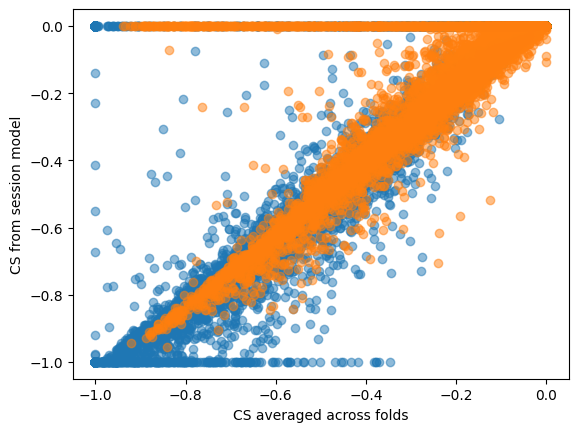

In [375]:
fig, ax = plt.subplots()
ax.scatter(coding_score_session_model_filtered.sel(model=single_models).values.flatten(),
           coding_score_from_mean_filtered.sel(model=single_models).values.flatten(),
           alpha=0.5)
ax.scatter(coding_score_session_model_filtered.sel(model=dropout_models).values.flatten(),
           coding_score_from_mean_filtered.sel(model=dropout_models).values.flatten(),
           alpha=0.5)
ax.set_xlabel('CS averaged across folds')
ax.set_ylabel('CS from session model')

# Choosing one
- Which one is less noisy?
- Proportion of clipped

In [152]:
temp_omission_cs = coding_score_avg_from_cv_filtered_before_clipping.sel(model='omissions') # after filtering but before clipping
len(np.where((temp_omission_cs > 0) | (temp_omission_cs < -1))[0])

171

In [148]:
temp_omission_cs = coding_score_from_mean_filtered_before_clipping.sel(model='omissions')
len(np.where((temp_omission_cs > 0) | (temp_omission_cs < -1))[0])

125

In [378]:
temp_omission_cs = coding_score_session_model_filtered_before_clipping.sel(model='omissions')
len(np.where((temp_omission_cs > 0) | (temp_omission_cs < -1))[0])

7

In [377]:
len(np.where(coding_score_avg_from_cv_filtered_before_clipping != coding_score_avg_from_cv_filtered)[0])

2369

In [376]:
len(np.where(coding_score_session_model_filtered_before_clipping != coding_score_session_model_filtered)[0])

599

# Conclusion
- use coding score calculation from the session model 
- Less noisier.
- Need to think about this more later, but for now...

# Matching with mean responses
- In another notebook
- Response from baseline and p-value from (https://codeocean.allenneuraldynamics.org/capsule/6152025/tree?cw=true)
    - Next version going to include event-locked traces
- Trace plotting from SessionStimResponse class
- Going to merge these two in the same class

In [171]:
from lamf_analysis.ophys.session_stim_response import SessionStimResponse
from lamf_analysis.ophys.bod_utils import load_bods_for_session
import lamf_analysis.ophys.stim_response_utils as sr_utils
    

In [172]:
ssr_path = '/root/capsule/data/multiplane-ophys_726963_stim-response/736963_2024-08-05_session_stim_response.h5'
session_stim_response = SessionStimResponse.load(ssr_path, format = "xarray")

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Cell 0 responses (omissions/events)'}, xlabel='Time (s)', ylabel='Response'>)

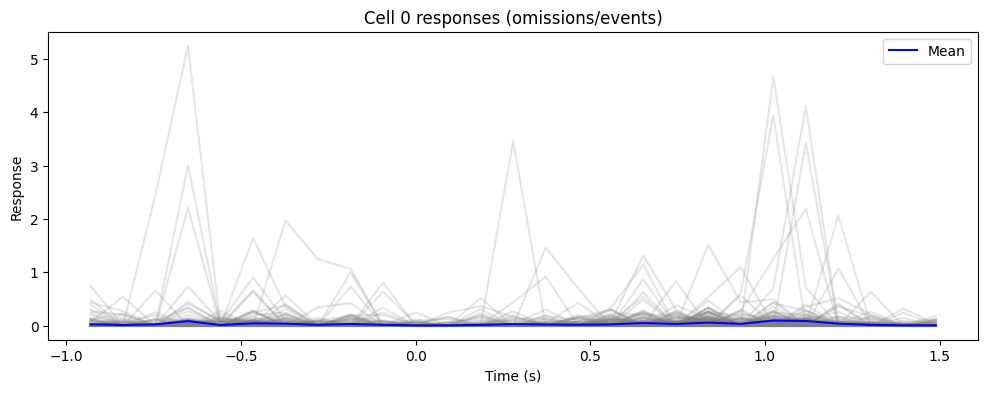

In [191]:
fig, ax = plt.subplots()
session_stim_response.plot_cell_response(0, 'VISp_0', 'omissions', 'events')

# Coding score validation
- Visual check
- Population comparison

In [211]:
session_name = session_names[5]
response_stats_df_fn = f'/root/capsule/scratch/Thyme/response_{session_name}.h5'
response_stats_df = pd.read_hdf(response_stats_df_fn)

response_stats_df = response_stats_df.reset_index(drop=False).rename(columns={'cell_roi_id': 'cell_roi_session_ind'})
response_stats_df['cell_roi_id'] = response_stats_df.apply(lambda x: f'{x.plane_name}_{x.cell_roi_session_ind:04}', axis=1)
response_stats_df.set_index('cell_roi_id', inplace=True, drop=True)

In [232]:
omission_events_df = response_stats_df.query('condition=="omitted" and data_type=="events"')
omission_dff_df = response_stats_df.query('condition=="omitted" and data_type=="dff"')

In [235]:
omission_scores = -coding_score_session_model_filtered.sel(model='omissions')
cell_roi_ids = omission_scores.cell_roi_id.values
omission_mean_responses_events = omission_events_df.loc[cell_roi_ids, 'response_from_baseline']
omission_pvalues_events = omission_events_df.loc[cell_roi_ids, 'p_value']
omission_mean_responses_dff = omission_dff_df.loc[cell_roi_ids, 'response_from_baseline']
omission_pvalues_dff = omission_dff_df.loc[cell_roi_ids, 'p_value']

Text(0, 0.5, 'Coding score')

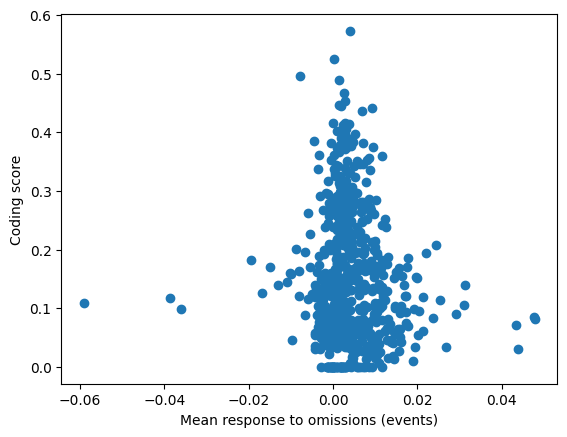

In [372]:
fig, ax = plt.subplots()
ax.scatter(omission_mean_responses_events, omission_scores)
ax.set_xlabel('Mean response to omissions (events)')
ax.set_ylabel('Coding score')

Text(0, 0.5, 'coding score')

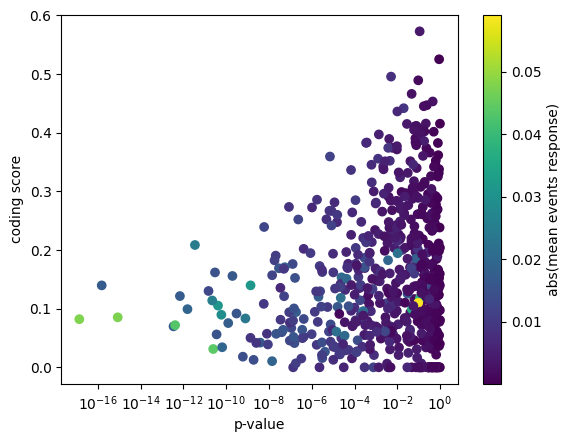

In [373]:
fig, ax = plt.subplots()
im = ax.scatter(omission_pvalues, omission_scores, c=abs(omission_mean_responses))
ax.set_xscale('log')
plt.colorbar(im).set_label('abs(mean events response)')
ax.set_xlabel('p-value')
ax.set_ylabel('coding score')

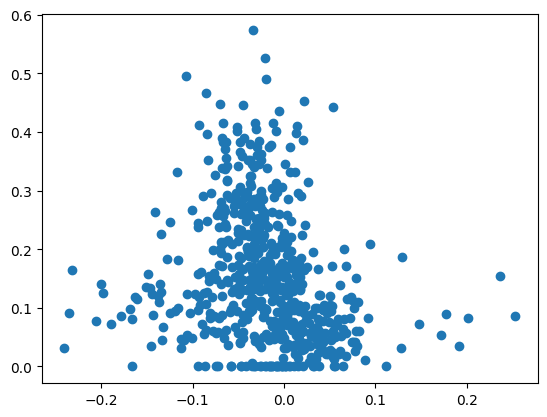

In [236]:
fig, ax = plt.subplots()
ax.scatter(omission_mean_responses_dff, omission_scores)

Text(0.5, 1.0, 'multiplane-ophys_736963_2024-08-05_09-19-25\ndff')

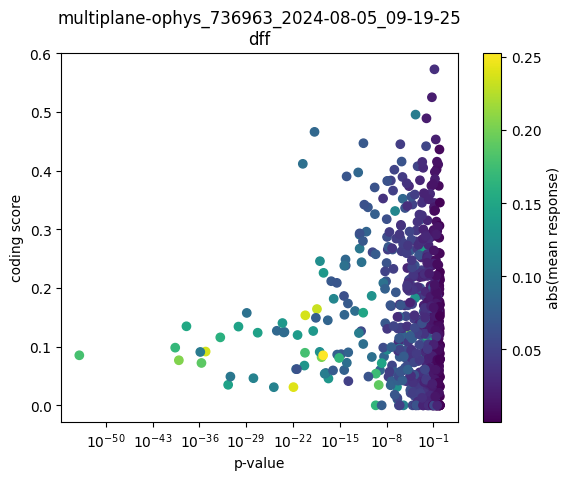

In [240]:
fig, ax = plt.subplots()
im = ax.scatter(omission_pvalues_dff, omission_scores, c=abs(omission_mean_responses_dff))
ax.set_xscale('log')
plt.colorbar(im).set_label('abs(mean response)')
ax.set_xlabel('p-value')
ax.set_ylabel('coding score')
ax.set_title(f'{session_name}\ndff')

(2.2247565574557328e-57,
 491.087535744127,
 1.9492397877760676e-18,
 491.087535744127)

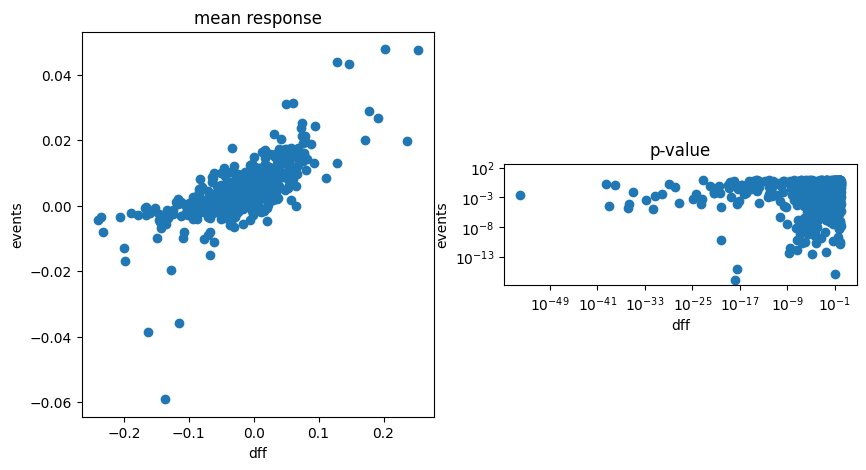

In [243]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(omission_mean_responses_dff, omission_mean_responses_events)
ax[0].set_xlabel('dff')
ax[0].set_ylabel('events')
ax[0].set_title('mean response')
ax[1].scatter(omission_pvalues_dff, omission_pvalues_events)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('dff')
ax[1].set_ylabel('events')
ax[1].set_title('p-value')
ax[1].axis('square')

### Look at individuals

In [250]:
sorted_inds = np.argsort(-omission_scores)
omission_scores[sorted_inds[0]]

<xarray.DataArray ()> Size: 8B
array(0.57283642)
Coordinates:
    model        <U9 36B 'omissions'
    cell_roi_id  <U11 44B 'VISp_0_0041'

In [351]:
adj_omissions_ve = adj_var_explained_session_model.sel(model='omissions')
adj_full_ve = adj_var_explained_session_model_full_mask.sel(model='omissions')
adj_ve_absolute = adj_full_ve - omissions_ve

In [368]:
float((1 - glm_omissions_adj_ve / glm_full_adj_ve).values)

0.0436890009246107

In [370]:
ind = sorted_inds[100]

omission_score = omission_scores.values[ind]
cell_roi_id = omission_scores.cell_roi_id.values[ind]
omission_mean_response_event = omission_mean_responses_events.loc[cell_roi_id]
omission_pvalue_event = omission_pvalues_dff.loc[cell_roi_id]
glm_full_adj_ve = adj_full_ve.sel(cell_roi_id=cell_roi_id)
glm_omissions_adj_ve = adj_omissions_ve.sel(cell_roi_id=cell_roi_id)
print(f'Cell ROI ID: {cell_roi_id}')
print(f'Mean response: {omission_mean_response_event:.3f}, p-value: {omission_pvalue_event:.3f}')
print(f'Coding score: {omission_score:.3f}\nGLM full adjVE: {glm_full_adj_ve:.3f}\nGLM omissions adjVE: {glm_omissions_adj_ve:.3f}')


Cell ROI ID: VISp_0_0055
Mean response: 0.004, p-value: 0.000
Coding score: 0.270
GLM full adjVE: 0.091
GLM omissions adjVE: 0.067


Text(0, 0.5, 'DFF')

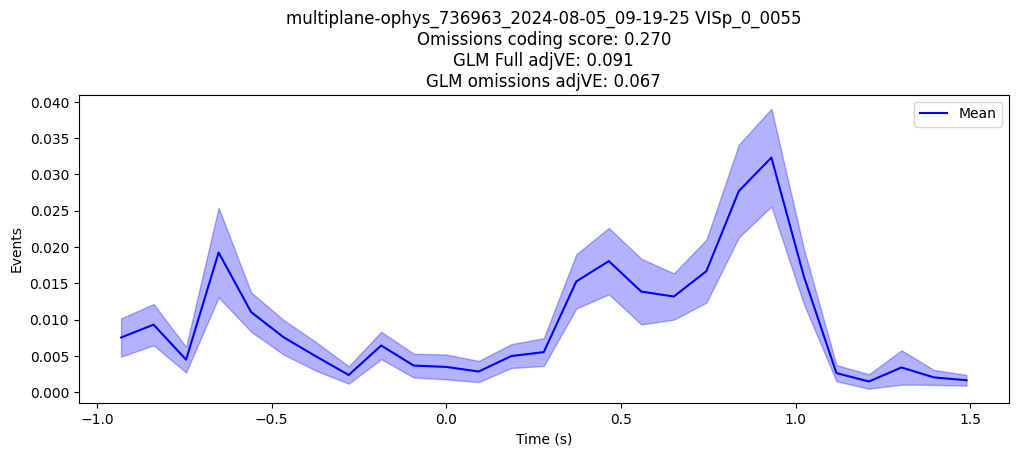

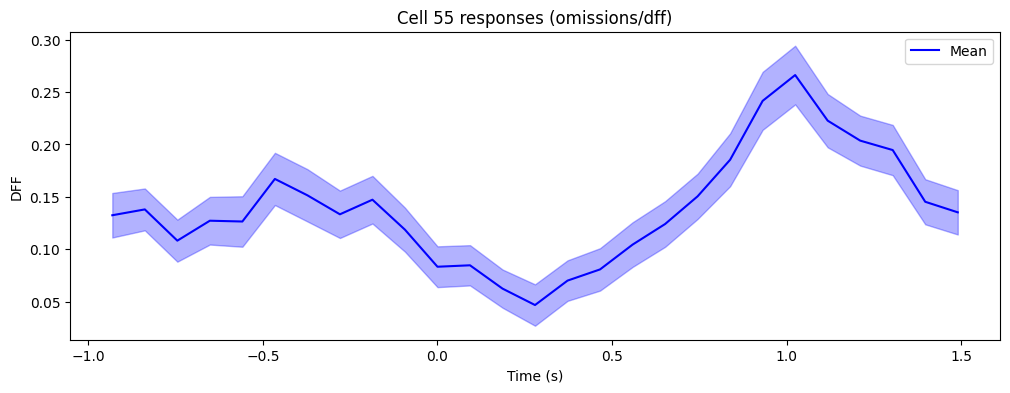

In [ ]:
plane = '_'.join(cell_roi_id.split('_')[:2])
cell_ind = int(cell_roi_id.split('_')[-1])

fig, ax = session_stim_response.plot_cell_response(cell_ind, plane, 'omissions', 'events', show_individual=False)
ax.set_title(f'{session_name} {cell_roi_id}\nOmissions coding score: {omission_score:.3f}\nGLM Full adjVE: {glm_full_adj_ve:.3f}\nGLM omissions adjVE: {glm_omissions_adj_ve:.3f}')
ax.set_ylabel('Events')


fig, ax = session_stim_response.plot_cell_response(cell_ind, plane, 'omissions', 'dff', show_individual=False)
ax.set_ylabel('DFF')

# Conclusion
- Assume they are correct.
    - Correlations are not great, but this can be an inherent problem with coding score calculation.
        - Asked questions to Marina and Iryna.
    - Proceed with this while
        - Curation response stats (https://codeocean.allenneuraldynamics.org/capsule/6152025/tree)
        - Checking with Marina and Iryna if there's any other way of validation.